<div style="background-color: #f0f7ff; padding: 20px; border-radius: 10px; border: 2px solid #007bff;">
    <h1 style="color: #4CAF50; margin-top: 0;">Project 1: Credit Card Default Prediction</h1>
    <p style="font-size: 1.1em;">
        <strong>Dataset Used:</strong> 
        The <a href="https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients">Default of Credit Card Clients</a> dataset from the UCI Machine Learning Repository.
    </p>
    <hr style="border: 0; border-top: 1px solid #007bff;">
    <h3 style="color: #0056b3;">Problem Statement</h3>
    <p style="line-height: 1.6;">
        The goal of this project is to build a binary classification model that predicts whether a client will default on their credit card payment. By analyzing historical behavior and demographics, we aim to help financial institutions identify high-risk borrowers and improve risk management through data-driven decisions.
    </p>
</div>

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix

In [2]:
# header=1 ensures that the second row is treated as column names 
df = pd.read_excel("default of credit card clients.xls", header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df.shape

(30000, 25)

# Cleaning the Dataset

In [4]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [5]:
# Rename target column to remove spaces for easier reference in code
df.rename(columns={"default payment next month": "default_payment_next_month"}, inplace=True)

# Confirm column names
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default_payment_next_month'],
      dtype='object')

In [6]:
# Drop the ID column because it is a unique identifier
# It does not provide predictive value for classification
df.drop(columns=["ID"], inplace=True)

# Check new dataset shape
df.shape

(30000, 24)

The dataset required adjustment because the first row contained descriptive labels rather than actual column headers. The dataset was reloaded using the appropriate header index. The ID column was removed since it does not contribute to prediction and could introduce noise.

In [7]:
# Display dataset information to check data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

All features are numerical. No immediate type conversion is required.

In [8]:
# Check for missing values in each column
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default_payment_next_month    0
dtype: int64

The dataset contains no missing values, eliminating the need for imputation.

In [9]:
# Count occurrences of each class
df['default_payment_next_month'].value_counts()

default_payment_next_month
0    23364
1     6636
Name: count, dtype: int64

In [10]:
# Calculate class proportions to evaluate imbalance
df['default_payment_next_month'].value_counts(normalize=True)

default_payment_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

The dataset is moderately imbalanced, with a higher proportion of non-default cases compared to default cases. This imbalance may influence model performance and evaluation metrics.

In [11]:
# descriptive statistics for numerical features
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Descriptive statistics lets us see feature variability, scale differences, and potential outliers. Significant variation in credit limit and bill amounts suggests that feature scaling will be necessary before model training.

Descriptive statistics reveal large variability in several financial variables.
Average billing amounts (BILL_AMT variables) are approximately $40,000–$50,000, while payment amounts (PAY_AMT variables) average around $4,000–$5,000. However, the maximum values for these features reach hundreds of thousands, indicating the presence of extreme values or outliers.

Because machine learning algorithms such as K-Nearest Neighbors and Support Vector Machines are sensitive to feature scale, feature scaling will be necessary before model training.

In [12]:
df['SEX'].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

In [13]:
df['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [14]:
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [15]:
# EDUCATION contains invalid categories: 0, 5, and 6
# These values represent unknown or undefined education levels
# grouping them into category 4 (Other)

df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

# Verify the updated distribution
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

In [16]:
# MARRIAGE has a category 0 which represents an undefined status
# grouping this into category 3 (Other)

df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

# Verify the updated distribution
df['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64

After cleaning, categorical variables now contain only valid and interpretable categories. Grouping rare or undefined values prevents models from learning patterns from categories with extremely small sample sizes.

# Exploratory Data Analysis (EDA)

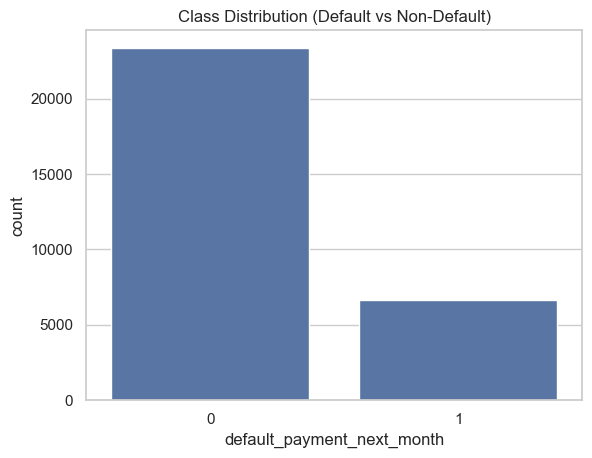

In [17]:
sns.set(style="whitegrid")

sns.countplot(x='default_payment_next_month', data=df)

plt.title("Class Distribution (Default vs Non-Default)")

plt.show()

The class distribution confirms that the dataset is imbalanced, with significantly more non-default cases than default cases. This imbalance must be considered when evaluating model performance.

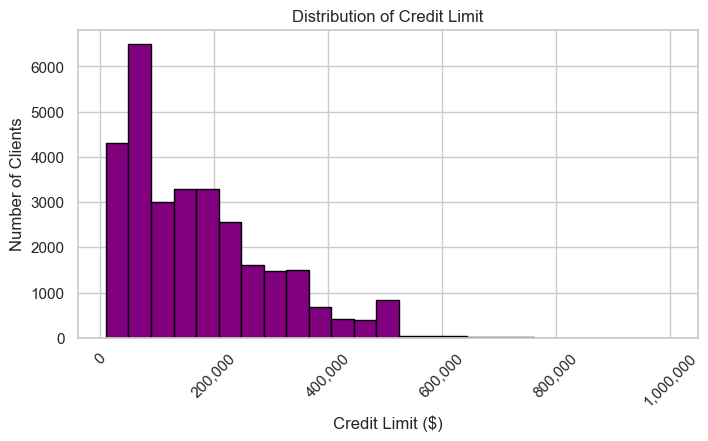

In [18]:
fig, ax1 = plt.subplots(figsize=(8, 4))
df['LIMIT_BAL'].hist(bins=25, color='purple', edgecolor='black', ax=ax1)
ax1.set_title("Distribution of Credit Limit")
ax1.set_xlabel("Credit Limit ($)")
ax1.set_ylabel("Number of Clients")
# Format axis to remove scientific notation
ax1.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45)
plt.show()

The distribution of credit limits is right-skewed. It shows that most clients have a credit limit between $0 and $200,000, with the highest concentration of individuals falling in the lower range. As the credit limit increases, the number of clients steadily decreases.

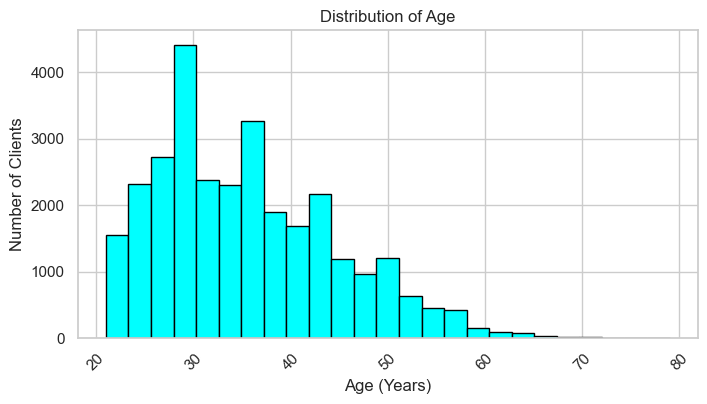

In [19]:
fig, ax1 = plt.subplots(figsize=(8, 4))
df['AGE'].hist(bins=25, color='aqua', edgecolor='black', ax=ax1)
ax1.set_title("Distribution of Age")
ax1.set_xlabel("Age (Years)")
ax1.set_ylabel("Number of Clients")
# Format axis to remove scientific notation
ax1.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45)
plt.show()

the Distribution of Age chart, also right-skewed, indicates that the majority of cardholders are in their late 20s to late 30s. There is a sharp decline in the number of clients after age 40. The dataset primarily represents a younger demographic of borrowers. Together, these graphs highlight that your typical client is a younger adult with a relatively modest credit line.

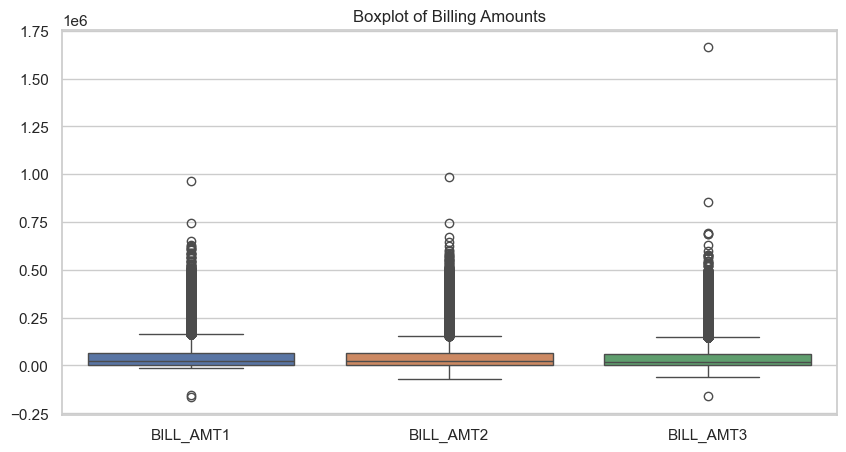

In [20]:
# Boxplot for bill amounts
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['BILL_AMT1','BILL_AMT2','BILL_AMT3']])

plt.title("Boxplot of Billing Amounts")

plt.show()

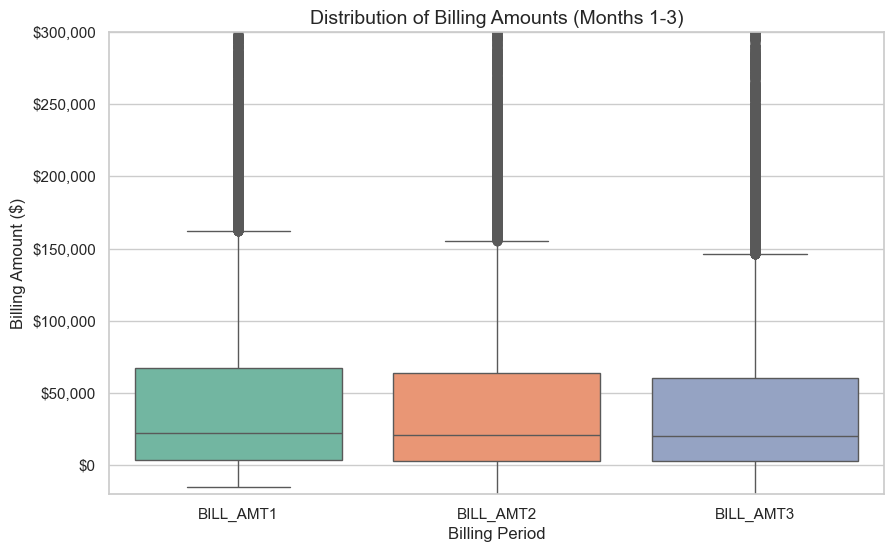

In [21]:
# Set a clean grid style
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Create boxplot with a better color palette
ax = sns.boxplot(data=df[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3']], palette="Set2")

# Title and labels
plt.title("Distribution of Billing Amounts (Months 1-3)", fontsize=14)
plt.ylabel("Billing Amount ($)", fontsize=12)
plt.xlabel("Billing Period", fontsize=12)

# Format the y-axis for standard currency (no scientific notation)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Cap the view to -20k and 300k to see the boxes more clearly 
# while still acknowledging the outliers exist
plt.ylim(-20000, 300000)

plt.show()

1. The typical billing range is quite low; most clients have monthly bills between $0 and $50,000
2. The median bill (the horizontal line inside each box) stays relatively consistent across the first three months, suggesting that the average customer's spending habits aren't fluctuating wildly.
3. There is a  massive number of outliers represented by the thick black lines extending far above the whiskers. These indicate a small group of heavy spenders whose balances are significantly higher than the rest of the population.
4. These outliers may influence model performance and will be addressed during preprocessing.

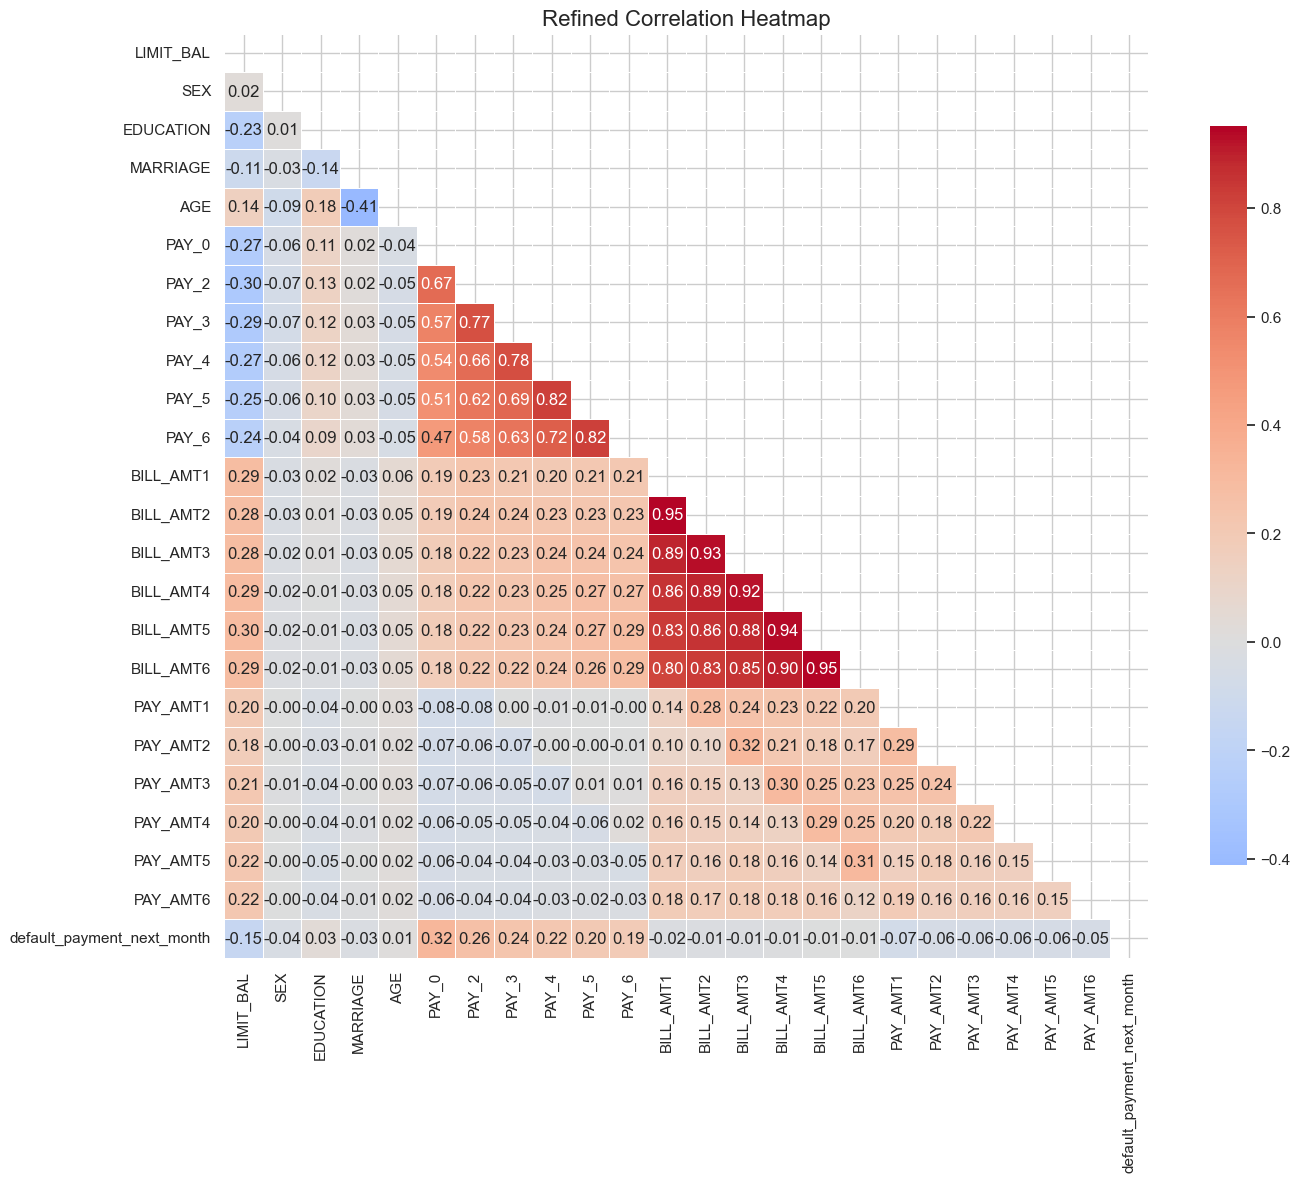

In [22]:
# Compute the correlation matrix
corr = df.corr()

# Create a mask to hide the top mirror-image half
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up a larger figure size for readability
plt.figure(figsize=(16, 12))

# Create the heatmap with numbers (annot) and a cleaner layout
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Refined Correlation Heatmap", fontsize=16)
plt.show()

1. bill amounts are very closely linked to each other, meaning if a client has a high bill one month, they usually have high bills in the following months too.
2. The most recent payment status has the strongest connection to whether a person will default. If someone is behind on their current payment, they are much more likely to miss the next
3. Personal details like age, education, and marriage status show almost no direct relationship with defaulting, suggesting that a person's financial behavior is a much better predictor than their demographics.

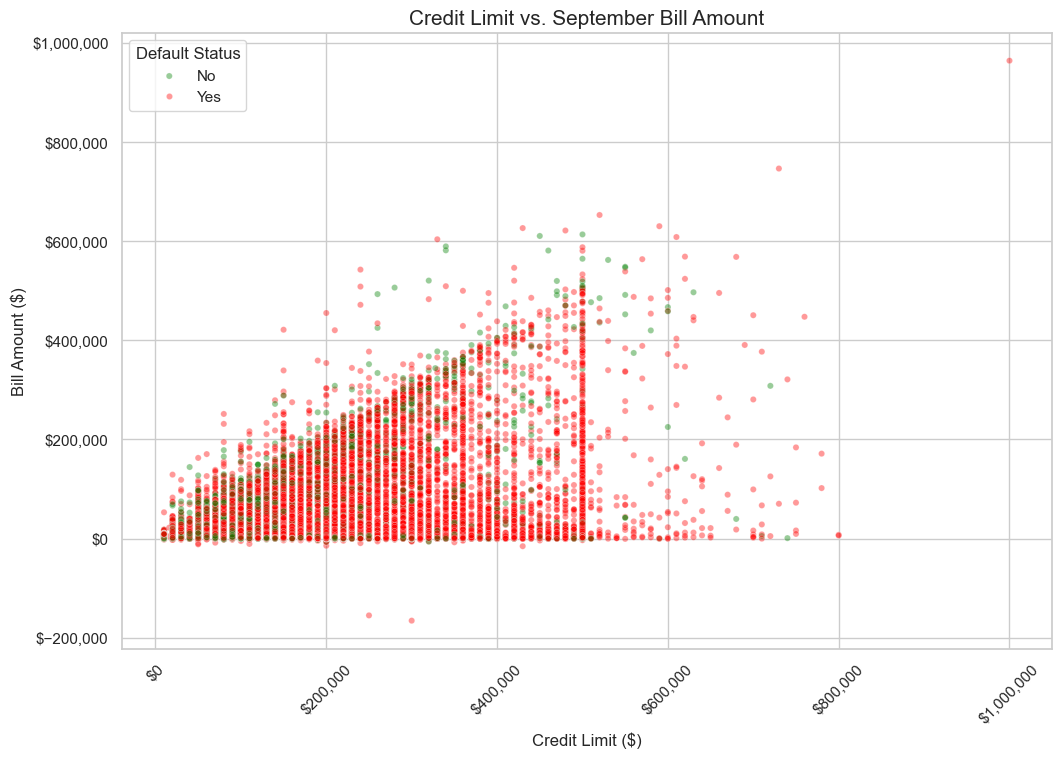

In [23]:
plt.figure(figsize=(12, 8))

# Added alpha for transparency and s for smaller point size
sns.scatterplot(x='LIMIT_BAL', y='BILL_AMT1', 
                hue='default_payment_next_month', 
                data=df, alpha=0.4, s=20, palette=["red", 'green'])

# Format axes to show currency and remove scientific notation
ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.title("Credit Limit vs. September Bill Amount", fontsize=15)
plt.xlabel("Credit Limit ($)", fontsize=12)
plt.ylabel("Bill Amount ($)", fontsize=12)
plt.legend(title="Default Status", labels=['No', 'Yes'])
plt.xticks(rotation=45)

plt.show()

The chart shows a strong concentration of clients with credit limits under 200,000 and monthly bills below 100,000. By using red for defaults and green for non-defaults, we can see that defaults (red dots) are spread across various credit limits and billing amounts, rather than being restricted to just high-debt individuals

# Feature Scaling

In [24]:
# Separate features (X) and target (y)
# We drop the target because clustering is UNSUPERVISED
X = df.drop(columns=['default_payment_next_month'])
y = df['default_payment_next_month']

# Initialize the scaler
scaler = StandardScaler()

# Scale the features so that each has mean = 0 and std = 1
X_scaled = scaler.fit_transform(X)

Feature scaling is applied to ensure that all variables contribute equally to the machine learning models. Since the dataset contains features with very different ranges (e.g., billing amounts in the hundreds of thousands and categorical variables with small integer values), models that rely on distance calculations, such as K-Nearest Neighbors and Support Vector Machines, can be heavily influenced by large-scale features.

StandardScaler is used to standardize the features by transforming them to have a mean of 0 and a standard deviation of 1. This improves model performance and ensures fair comparison between features.

In [25]:
# List to store Within-Cluster Sum of Squares (WCSS)
wcss = []

# Run KMeans for k = 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)  # Fit model on scaled data
    wcss.append(kmeans.inertia_)  # Store inertia (WCSS)

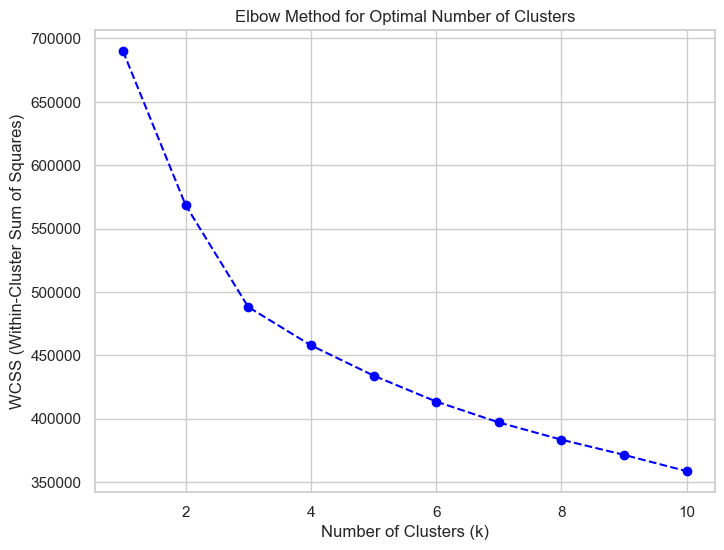

In [26]:
# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color="blue")

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')

plt.grid(True)
plt.show()

I chose $k=2$ because the Elbow Method graph shows the most significant "bend" or drop in cost right at the second cluster.  Since the goal of this project is to analyze credit defaults, a value of 2 is also makes sense with the binary nature of the data, as it allows the algorithm to naturally separate the clients into two primary groups based on their financial behavior and risk levels.

In [27]:
print(f"inertia: {kmeans.inertia_}")

inertia: 358643.3034152235


A value of 358643.30 means that the total squared distance between each data point and the centroid of its cluster is approximately 358643.30.

In [28]:
# Apply KMeans with chosen number of clusters
kmeans = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10, random_state=42)

# Fit and predict cluster labels
y_kmeans = kmeans.fit_predict(X_scaled)

# Implementing PCA

In [29]:
# Reduce dimensions to 2 for visualization
pca = PCA(n_components=2)

# Transform scaled data
X_pca = pca.fit_transform(X_scaled)

Principal Component Analysis (PCA) is a dimensionality reduction technique used to reduce the number of features while preserving as much variance as possible. This is particularly useful when features are highly correlated, as observed in the correlation heatmap for billing and payment variables.

* pca used to reduce the dimensionality of the data from 23 dimensions to 2 for visualizing, which makes it easier to plot data 
* n_components = 2, reducess the data to 2 dimensions, to view in 2D scatter plot

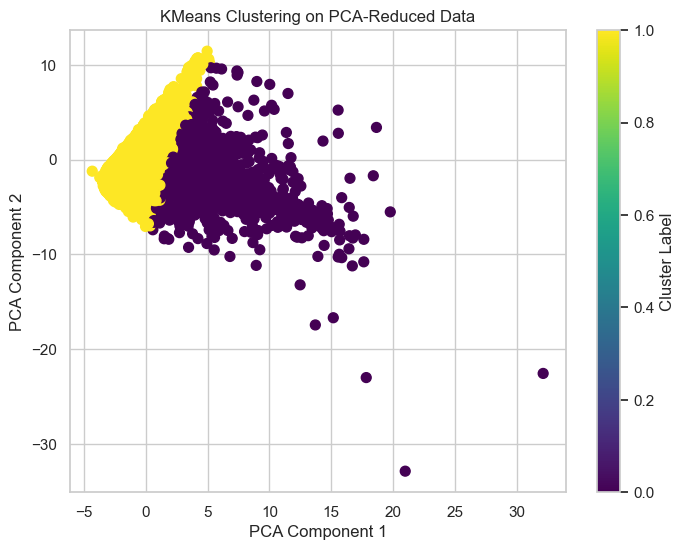

In [30]:
# Plot clusters
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', s=50)

plt.title("KMeans Clustering on PCA-Reduced Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.colorbar(label='Cluster Label')
plt.show()

In [31]:
# Create a pipeline that standardizes data, reduces dimensions, and applies KMeans
pipeline = make_pipeline(
    StandardScaler(),      # Step 1: Scale features
    PCA(n_components=2),   # Step 2: Reduce to 2D for visualization
    KMeans(n_clusters=2, random_state=42)  # Step 3: Apply KMeans
)

# Fit the pipeline to the data
pipeline.fit(X)

# Extract cluster labels from KMeans step
labels = pipeline.named_steps['kmeans'].labels_

In [32]:
# Apply transformations step by step for visualization

# Step 1: Scale data
X_scaled_pipeline = pipeline.named_steps['standardscaler'].transform(X)

# Step 2: Apply PCA
X_pca_pipeline = pipeline.named_steps['pca'].transform(X_scaled_pipeline)

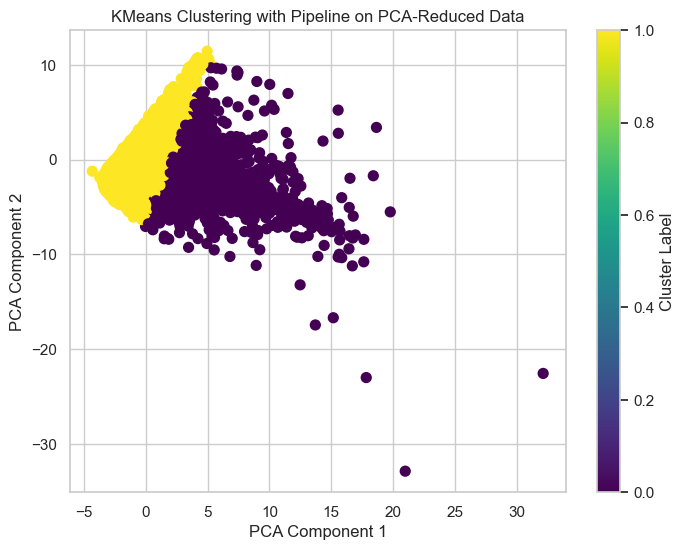

In [33]:
plt.figure(figsize=(8, 6))

# Scatter plot with cluster labels
plt.scatter(X_pca_pipeline[:, 0], X_pca_pipeline[:, 1], c=labels, cmap='viridis', s=50)

plt.title("KMeans Clustering with Pipeline on PCA-Reduced Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.colorbar(label='Cluster Label')
plt.show()

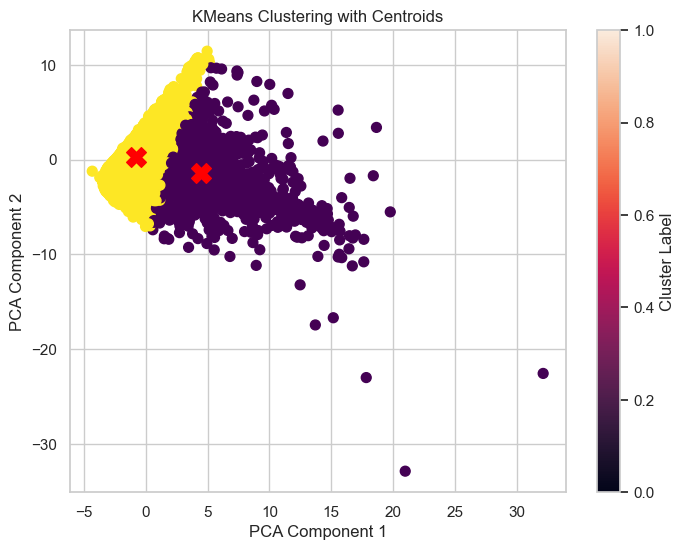

In [34]:
# Transform centroids into PCA space
centroids = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))

# Plot data points
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', s=50, label='Data Points')

# Plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Data Points')

plt.title("KMeans Clustering with Centroids")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.colorbar(label='Cluster Label')
plt.show()

In [35]:
# Print cluster centers
print("Cluster Centers:")
print(kmeans.cluster_centers_)

Cluster Centers:
[[ 0.7109824  -0.04415862 -0.04396699 -0.09809596  0.13772259  0.32268767
   0.38616561  0.38842885  0.40694443  0.43559242  0.4488276   1.74307879
   1.79327174  1.80520577  1.8311369   1.81688621  1.78607629  0.52745542
   0.40601367  0.45843422  0.43542468  0.44516622  0.38311889]
 [-0.13064929  0.00811454  0.00807932  0.018026   -0.02530774 -0.05929671
  -0.07096134 -0.07137723 -0.07477963 -0.08004395 -0.08247603 -0.32030612
  -0.32952951 -0.3317225  -0.33648757 -0.33386888 -0.32820729 -0.09692459
  -0.0746086  -0.08424134 -0.08001313 -0.08180322 -0.07040148]]


* Row represents the coordinates of a centroid in the original feature space

In [36]:
# Print first 5 data points with cluster labels
print("\nFirst 5 data points with cluster labels:")
for i in range(5):
    print(f"Cluster Label: {y_kmeans[i]}")


First 5 data points with cluster labels:
Cluster Label: 1
Cluster Label: 1
Cluster Label: 1
Cluster Label: 1
Cluster Label: 1


In [37]:
# Add cluster labels to dataframe
df['Cluster'] = y_kmeans

# Calculate default rate per cluster
cluster_analysis = df.groupby('Cluster')['default_payment_next_month'].mean()

# Display results
cluster_analysis

Cluster
0    0.213411
1    0.222630
Name: default_payment_next_month, dtype: float64

The default rates across clusters are very similar, indicating that K-Means clustering did not strongly differentiate customers based on default behavior. This suggests that default risk is influenced by more complex relationships between variables that cannot be captured through simple distance-based clustering.

### Splitting the data

In [38]:
# Split dataset into training and testing sets
# 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Building Pipelines

In [39]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),  # Scale features
    ('pca', PCA(n_components=0.95)),  # Reduce dimensionality
    ('model', LogisticRegression(max_iter=1000))
])

pipeline_rf = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('model', SVC())
])

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('model', KNeighborsClassifier())
])

# Cross Validation

In [40]:
# Perform 5-fold cross-validation for each model

cv_lr = cross_val_score(pipeline_lr, X_train, y_train, cv=5, scoring='accuracy')
cv_rf = cross_val_score(pipeline_rf, X_train, y_train, cv=5, scoring='accuracy')
cv_svm = cross_val_score(pipeline_svm, X_train, y_train, cv=5, scoring='accuracy')
cv_knn = cross_val_score(pipeline_knn, X_train, y_train, cv=5, scoring='accuracy')

In [41]:
# Print mean accuracy for each model

print("Logistic Regression CV Accuracy:", cv_lr.mean())
print("Random Forest CV Accuracy:", cv_rf.mean())
print("SVM CV Accuracy:", cv_svm.mean())
print("KNN CV Accuracy:", cv_knn.mean())

Logistic Regression CV Accuracy: 0.8102499999999999
Random Forest CV Accuracy: 0.815625
SVM CV Accuracy: 0.8163333333333334
KNN CV Accuracy: 0.79375


In [42]:
# Print standard deviation (variability)

print("LR Std Dev:", cv_lr.std())
print("RF Std Dev:", cv_rf.std())
print("SVM Std Dev:", cv_svm.std())
print("KNN Std Dev:", cv_knn.std())

LR Std Dev: 0.0035804251764901315
RF Std Dev: 0.0009033118078616093
SVM Std Dev: 0.0015229722402080679
KNN Std Dev: 0.0027888667551135633


Cross-validation provides a more reliable estimate of model performance by averaging results across multiple folds. The mean accuracy represents overall performance, while the standard deviation indicates variability.

A lower standard deviation suggests that the model performs consistently across different subsets of the data, while a higher value indicates instability.

After running 5-fold cross-validation, the SVM (Support Vector Machine) emerged as the top performer with a mean accuracy of 81.6%, closely followed by the Random Forest at 81.5%. While their accuracies are nearly identical, the Random Forest is actually the most "reliable" model because it has the lowest Standard Deviation (0.0009). This low variability means the Random Forest is very stable and provides consistent results no matter which subset of data it looks at, whereas the KNN model struggled both in accuracy (79.3%) and consistency.

# Model Evaluation

After training and cross-validation, the models are evaluated on the test dataset to measure their performance on unseen data. Evaluation metrics include accuracy, confusion matrix, and ROC-AUC score.

In [43]:
# Fit each pipeline on training data

pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)
pipeline_svm.fit(X_train, y_train)
pipeline_knn.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)),
                ('model', KNeighborsClassifier())])

In [44]:
# Generate predictions on test set

y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)
y_pred_svm = pipeline_svm.predict(X_test)
y_pred_knn = pipeline_knn.predict(X_test)

In [45]:
print("LR Test Accuracy:", accuracy_score(y_test, y_pred_lr))
print("RF Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("SVM Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("KNN Test Accuracy:", accuracy_score(y_test, y_pred_knn))

LR Test Accuracy: 0.8073333333333333
RF Test Accuracy: 0.8141666666666667
SVM Test Accuracy: 0.8105
KNN Test Accuracy: 0.7923333333333333


In [47]:
# Compute confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("LR Confusion Matrix:\n", cm_lr)
print("RF Confusion Matrix:\n", cm_rf)
print("SVM Confusion Matrix:\n", cm_svm)
print("KNN Confusion Matrix:\n", cm_knn)

LR Confusion Matrix:
 [[4531  142]
 [1014  313]]
RF Confusion Matrix:
 [[4408  265]
 [ 850  477]]
SVM Confusion Matrix:
 [[4380  293]
 [ 844  483]]
KNN Confusion Matrix:
 [[4290  383]
 [ 863  464]]


In [48]:
# Get probabilities (needed for ROC)
lr_probs = pipeline_lr.predict_proba(X_test)[:, 1]
rf_probs = pipeline_rf.predict_proba(X_test)[:, 1]
svm_probs = pipeline_svm.decision_function(X_test)  # SVM uses decision function
knn_probs = pipeline_knn.predict_proba(X_test)[:, 1]

# Compute ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_probs)

# Compute AUC
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_svm = auc(fpr_svm, tpr_svm)
auc_knn = auc(fpr_knn, tpr_knn)

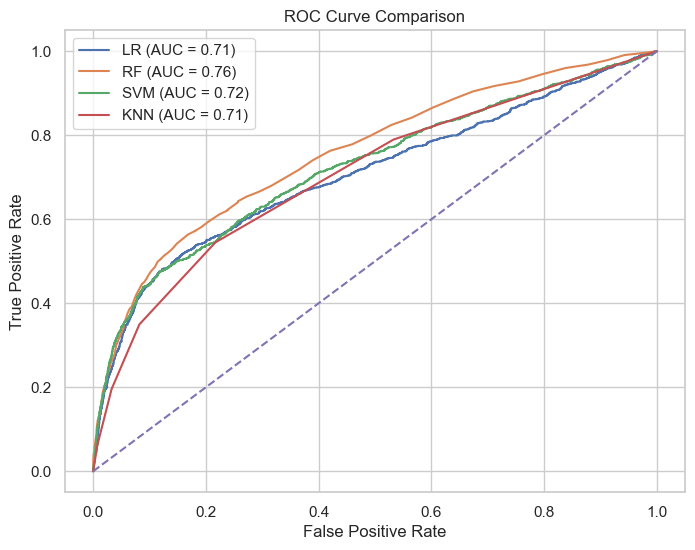

In [49]:
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC = {auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC = {auc_rf:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})")

plt.plot([0,1], [0,1], linestyle='--')  # Random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()